# HR Database Analysis

This notebook demonstrates how to use SQL within Jupyter to query and analyze an HR database.  
The analysis covers employee roles, salary ranges, job history, and department structure.

Tools used:
- SQLite (local database)
- `ipython-sql` for SQL magic
- Pandas for analysis

In [441]:
!pip install ipython-sql

Load required libraries

In [442]:
import pandas as pd
import sqlite3

Connection to the database

In [443]:
conn = sqlite3.connect("HR.db")

Configuration for SQL Magic

In [444]:
%load_ext sql
%sql sqlite:///HR.db
%config SqlMagic.autopandas = True

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


Reading data from csv files and adding headers

In [445]:
df_departments = pd.read_csv("C:/Workspace/HR/Departments.csv", header=None)
df_employees = pd.read_csv("C:/Workspace/HR/Employees.csv", header=None)
df_jobs = pd.read_csv("C:/Workspace/HR/Jobs.csv", header=None)
df_jobs_history = pd.read_csv("C:/Workspace/HR/JobsHistory.csv", header=None)
df_locations = pd.read_csv("C:/Workspace/HR/Locations.csv", header=None)

In [446]:
headers = ["DEPT_ID_DEP", "DEP_NAME", "MANAGER_ID", "LOC_ID"]
df_departments.columns = headers
df_departments.head()

,DEPT_ID_DEP,DEP_NAME,MANAGER_ID,LOC_ID
0,2,Architect Group,30001,L0001
1,5,Software Group,30002,L0002
2,7,Design Team,30003,L0003


In [447]:
headers = ["EMP_ID", "F_NAME", "L_NAME", "SSN", "B_DATE", "SEX", "ADDRESS", "JOB_ID", "SALARY", "MANAGER_ID", "DEP_ID" ]
df_employees.columns = headers
df_employees.head()

,EMP_ID,F_NAME,L_NAME,SSN,B_DATE,SEX,ADDRESS,JOB_ID,SALARY,MANAGER_ID,DEP_ID
0,E1001,John,Thomas,123456,1976-09-01,M,"5631 Rice, OakPark,IL",100,100000,30001,2
1,E1002,Alice,James,123457,1972-07-31,F,"980 Berry ln, Elgin,IL",200,80000,30002,5
2,E1003,Steve,Wells,123458,1980-10-08,M,"291 Springs, Gary,IL",300,50000,30002,5
3,E1004,Santosh,Kumar,123459,1985-07-20,M,"511 Aurora Av, Aurora,IL",400,60000,30002,5
4,E1005,Ahmed,Hussain,123410,1981-04-01,M,"216 Oak Tree, Geneva,IL",500,70000,30001,2


In [448]:
headers = ["JOB_IDENT", "JOB_TITLE", "MIN_SALARY", "MAX_SALARY"]
df_jobs.columns = headers
df_jobs.head()

,JOB_IDENT,JOB_TITLE,MIN_SALARY,MAX_SALARY
0,100,Sr. Architect,60000,100000
1,200,Sr. Software Developer,60000,80000
2,300,Jr.Software Developer,40000,60000
3,400,Jr.Software Developer,40000,60000
4,500,Jr. Architect,50000,70000


In [449]:
headers = ["EMPL_ID", "START_DATE", "JOBS_ID", "DEPT_ID"]
df_jobs_history.columns = headers
df_jobs_history.head()

,EMPL_ID,START_DATE,JOBS_ID,DEPT_ID
0,E1001,2000-08-01,100,2
1,E1002,2001-08-01,200,5
2,E1003,2001-08-16,300,5
3,E1004,2000-08-16,400,5
4,E1005,2000-05-30,500,2


In [450]:
headers = ["LOCT_ID", "DEP_ID_LOC"]
df_locations.columns = headers
df_locations.head()

,LOCT_ID,DEP_ID_LOC
0,L0001,2
1,L0002,5
2,L0003,7


Creating tables in the database

In [451]:
df_departments.to_sql("DEPARTMENTS", conn, if_exists="replace", index=False)
df_employees.to_sql("EMPLOYEES", conn, if_exists="replace", index=False)
df_jobs.to_sql("JOBS", conn, if_exists="replace", index=False)
df_jobs_history.to_sql("JOB_HISTORY", conn, if_exists="replace", index=False)
df_locations.to_sql("LOCATIONS", conn, if_exists="replace", index=False)

3

## String Patterns, Sorting and Grouping

Retrieving the list of all employees, first and last names, whose first names start with ‘A’.

In [452]:
query = """
SELECT F_NAME, L_NAME FROM EMPLOYEES WHERE F_NAME LIKE "A%";
"""
df = pd.read_sql_query(query, conn)
df

,F_NAME,L_NAME
0,Alice,James
1,Ahmed,Hussain
2,Andrea,Jones
3,Ann,Jacob


Arranging all the records of the EMPLOYEES table in ascending order of the date of birth.

In [453]:
query = """
SELECT * FROM EMPLOYEES ORDER BY B_DATE;
"""
df = pd.read_sql_query(query, conn)
df

,EMP_ID,F_NAME,L_NAME,SSN,B_DATE,SEX,ADDRESS,JOB_ID,SALARY,MANAGER_ID,DEP_ID
0,E1002,Alice,James,123457,1972-07-31,F,"980 Berry ln, Elgin,IL",200,80000,30002,5
1,E1007,Mary,Thomas,123412,1975-05-05,F,"100 Rose Pl, Gary,IL",650,65000,30003,7
2,E1001,John,Thomas,123456,1976-09-01,M,"5631 Rice, OakPark,IL",100,100000,30001,2
3,E1006,Nancy,Allen,123411,1978-06-02,F,"111 Green Pl, Elgin,IL",600,90000,30001,2
4,E1003,Steve,Wells,123458,1980-10-08,M,"291 Springs, Gary,IL",300,50000,30002,5
5,E1005,Ahmed,Hussain,123410,1981-04-01,M,"216 Oak Tree, Geneva,IL",500,70000,30001,2
6,E1010,Ann,Jacob,123415,1982-03-30,F,"111 Britany Springs,Elgin,IL",220,70000,30002,5
7,E1008,Bharath,Gupta,123413,1985-06-05,M,"145 Berry Ln, Naperville,IL",660,65000,30003,7
8,E1004,Santosh,Kumar,123459,1985-07-20,M,"511 Aurora Av, Aurora,IL",400,60000,30002,5
9,E1009,Andrea,Jones,123414,1990-09-07,F,"120 Fall Creek, Gary,IL",234,70000,30003,7


Grouping the records in terms of the department IDs and filtering them of ones that have average salary more than or equal to 60000. Displaying the department ID and the average salary.

In [454]:
query = """
SELECT DEP_ID, AVG(SALARY) 
FROM EMPLOYEES
GROUP BY DEP_ID
HAVING AVG(SALARY) >= 60000;
"""
df = pd.read_sql_query(query, conn)
df

,DEP_ID,AVG(SALARY)
0,2,86666.666667
1,5,65000.000000
2,7,66666.666667


For the problem above, sorting the results for each group in descending order of average salary.

In [455]:
query = """
SELECT DEP_ID, AVG(SALARY) 
FROM EMPLOYEES
GROUP BY DEP_ID
HAVING AVG(SALARY) >= 60000
ORDER BY AVG(SALARY) DESC;
"""
df = pd.read_sql_query(query, conn)
df

,DEP_ID,AVG(SALARY)
0,2,86666.666667
1,7,66666.666667
2,5,65000.000000


Department list with the number of employees in each department

In [456]:
query = """
SELECT DEP_ID, COUNT(*) AS EMPLOYEE_COUNT
FROM EMPLOYEES
GROUP BY DEP_ID
"""
df = pd.read_sql_query(query, conn)
df

,DEP_ID,EMPLOYEE_COUNT
0,2,3
1,5,4
2,7,3


## Built-in functions

What is the lowest salary among all employees?

In [457]:
query = """
SELECT MIN(SALARY) AS LOWEST_SALARY FROM EMPLOYEES;
"""
df = pd.read_sql_query(query, conn)
df

,LOWEST_SALARY
0,50000


Which employee has worked in the company the longest and how long?

In [458]:
query = """
SELECT EMPL_ID, ROUND((julianday('now') - julianday(START_DATE))/365, 0) AS YEARS_WORKED 
FROM JOB_HISTORY
ORDER BY START_DATE ASC
LIMIT 1
"""
df = pd.read_sql_query(query, conn)
df

,EMPL_ID,YEARS_WORKED
0,E1005,25.0


What is the age of each employee (based on their birth date)?

In [459]:
query = """
SELECT F_NAME, L_NAME, ROUND((julianday('now') - julianday(B_DATE))/365, 0) AS AGE
FROM EMPLOYEES;
"""
df = pd.read_sql_query(query, conn)
df

,F_NAME,L_NAME,AGE
0,John,Thomas,49.0
1,Alice,James,53.0
2,Steve,Wells,45.0
3,Santosh,Kumar,40.0
4,Ahmed,Hussain,44.0
5,Nancy,Allen,47.0
6,Mary,Thomas,50.0
7,Bharath,Gupta,40.0
8,Andrea,Jones,35.0
9,Ann,Jacob,43.0


Who is the employee with the lowest salary?

In [460]:
query = """
SELECT F_NAME, L_NAME
FROM EMPLOYEES
ORDER BY SALARY ASC
LIMIT 1;
"""
df = pd.read_sql_query(query, conn)
df

,F_NAME,L_NAME
0,Steve,Wells


Which department has the highest average salary?

In [461]:
query = """
SELECT DEP_ID, AVG(SALARY) AS AVERAGE_SALARY
FROM EMPLOYEES
GROUP BY DEP_ID
ORDER BY AVG(SALARY) DESC
LIMIT 1
"""
df = pd.read_sql_query(query, conn)
df

,DEP_ID,AVERAGE_SALARY
0,2,86666.666667


## Sub-queries and Nested Selects

What is the salary range in the Software Group?

In [462]:
query = """
SELECT MIN(SALARY), MAX(SALARY)
FROM EMPLOYEES
WHERE DEP_ID = (SELECT DEPT_ID_DEP FROM DEPARTMENTS WHERE DEP_NAME = "Software Group")
"""
df = pd.read_sql_query(query, conn)
df

,MIN(SALARY),MAX(SALARY)
0,50000,80000


Find the average salary of the five least-earning employees.

In [463]:
query = """
SELECT AVG(SALARY) 
FROM (SELECT SALARY FROM EMPLOYEES ORDER BY SALARY ASC LIMIT 5) AS SALARY_TABLE;
"""
df = pd.read_sql_query(query, conn)
df

,AVG(SALARY)
0,62000.0


Find the records of employees older than the average age of all employees.

In [464]:
query = """
SELECT F_NAME, L_NAME, (julianday('now') - julianday(B_DATE))/365 AS AGE
FROM EMPLOYEES 
WHERE (julianday('now') - julianday(B_DATE))/365 > (SELECT AVG(julianday('now') - julianday(B_DATE))/365 AS AVERAGE_AGE FROM EMPLOYEES)
"""
df = pd.read_sql_query(query, conn)
df

,F_NAME,L_NAME,AGE
0,John,Thomas,48.678047
1,Alice,James,52.768458
2,Steve,Wells,44.573938
3,Nancy,Allen,46.927362
4,Mary,Thomas,50.006814


From the Job_History table, display the list of Employee IDs, years of service, and average years of service for all entries.

In [465]:
query = """
SELECT EMPL_ID, ROUND((julianday('now') - julianday(START_DATE))/365, 2) AS YEARS_OF_SERVICE, 
    (SELECT ROUND(AVG(julianday('now') - julianday(START_DATE))/365, 2)
    FROM JOB_HISTORY) AS AVERAGE_YEARS_OF_SERVICE
FROM JOB_HISTORY
"""
df = pd.read_sql_query(query, conn)
df

,EMPL_ID,YEARS_OF_SERVICE,AVERAGE_YEARS_OF_SERVICE
0,E1001,24.75,20.08
1,E1002,23.75,20.08
2,E1003,23.71,20.08
3,E1004,24.71,20.08
4,E1005,24.92,20.08
5,E1006,23.71,20.08
6,E1007,22.92,20.08
7,E1008,14.98,20.08
8,E1009,8.69,20.08
9,E1010,8.69,20.08


## Working with multiple Tables

Retrieve only the list of employees whose JOB_TITLE is Jr. Designer.\
a. Using sub-queries

In [466]:
query = """
SELECT *
FROM EMPLOYEES 
WHERE JOB_ID IN (SELECT JOB_IDENT 
                FROM JOBS 
                WHERE JOB_TITLE = "Jr. Designer")
"""
df = pd.read_sql_query(query, conn)
df

,EMP_ID,F_NAME,L_NAME,SSN,B_DATE,SEX,ADDRESS,JOB_ID,SALARY,MANAGER_ID,DEP_ID
0,E1007,Mary,Thomas,123412,1975-05-05,F,"100 Rose Pl, Gary,IL",650,65000,30003,7
1,E1008,Bharath,Gupta,123413,1985-06-05,M,"145 Berry Ln, Naperville,IL",660,65000,30003,7


b. Using Implicit Joins

In [467]:
query = """
SELECT *
FROM EMPLOYEES E, JOBS J
WHERE E.JOB_ID = J.JOB_IDENT
AND J.JOB_TITLE = "Jr. Designer"
"""
df = pd.read_sql_query(query, conn)
df

,EMP_ID,F_NAME,L_NAME,SSN,B_DATE,SEX,ADDRESS,JOB_ID,SALARY,MANAGER_ID,DEP_ID,JOB_IDENT,JOB_TITLE,MIN_SALARY,MAX_SALARY
0,E1007,Mary,Thomas,123412,1975-05-05,F,"100 Rose Pl, Gary,IL",650,65000,30003,7,650,Jr. Designer,60000,70000
1,E1008,Bharath,Gupta,123413,1985-06-05,M,"145 Berry Ln, Naperville,IL",660,65000,30003,7,660,Jr. Designer,60000,70000


Retrieve JOB information and a list of employees whose birth year is after 1976.\
a. Using sub-queries

In [468]:
query = """
SELECT *
FROM JOBS
WHERE JOB_IDENT IN (SELECT JOB_ID
                FROM EMPLOYEES 
                WHERE CAST(strftime('%Y', B_DATE) AS INTEGER) > 1976)
"""
df = pd.read_sql_query(query, conn)
df

,JOB_IDENT,JOB_TITLE,MIN_SALARY,MAX_SALARY
0,300,Jr.Software Developer,40000,60000
1,400,Jr.Software Developer,40000,60000
2,500,Jr. Architect,50000,70000
3,600,Lead Architect,70000,100000
4,660,Jr. Designer,60000,70000
5,234,Sr. Designer,70000,90000
6,220,Sr. Designer,70000,90000


b. Using implicit join

In [469]:
query = """
SELECT J.JOB_IDENT,	J.JOB_TITLE,	J.MIN_SALARY,	J.MAX_SALARY
FROM JOBS J, EMPLOYEES E
WHERE E.JOB_ID = J.JOB_IDENT AND CAST(strftime('%Y', B_DATE) AS INTEGER) > 1976
"""
df = pd.read_sql_query(query, conn)
df

,JOB_IDENT,JOB_TITLE,MIN_SALARY,MAX_SALARY
0,300,Jr.Software Developer,40000,60000
1,400,Jr.Software Developer,40000,60000
2,500,Jr. Architect,50000,70000
3,600,Lead Architect,70000,100000
4,660,Jr. Designer,60000,70000
5,234,Sr. Designer,70000,90000
6,220,Sr. Designer,70000,90000


List of employees with department name and location

In [470]:
query = """
SELECT E.F_NAME, E.L_NAME, D.DEP_NAME, L.LOCT_ID
FROM EMPLOYEES E
JOIN DEPARTMENTS D ON E.DEP_ID = D.DEPT_ID_DEP
JOIN LOCATIONS L ON D.LOC_ID = L.LOCT_ID
"""
df = pd.read_sql_query(query, conn)
df

,F_NAME,L_NAME,DEP_NAME,LOCT_ID
0,John,Thomas,Architect Group,L0001
1,Alice,James,Software Group,L0002
2,Steve,Wells,Software Group,L0002
3,Santosh,Kumar,Software Group,L0002
4,Ahmed,Hussain,Architect Group,L0001
5,Nancy,Allen,Architect Group,L0001
6,Mary,Thomas,Design Team,L0003
7,Bharath,Gupta,Design Team,L0003
8,Andrea,Jones,Design Team,L0003
9,Ann,Jacob,Software Group,L0002


History of employment and job title

In [471]:
query = """
SELECT E.F_NAME, E.L_NAME, J.JOB_TITLE, JH.START_DATE
FROM EMPLOYEES E
JOIN JOBS J ON J.JOB_IDENT = E.JOB_ID
JOIN JOB_HISTORY JH ON JH.JOBS_ID = J.JOB_IDENT
"""
df = pd.read_sql_query(query, conn)
df

,F_NAME,L_NAME,JOB_TITLE,START_DATE
0,John,Thomas,Sr. Architect,2000-08-01
1,Alice,James,Sr. Software Developer,2001-08-01
2,Steve,Wells,Jr.Software Developer,2001-08-16
3,Santosh,Kumar,Jr.Software Developer,2000-08-16
4,Ahmed,Hussain,Jr. Architect,2000-05-30
5,Nancy,Allen,Lead Architect,2001-08-16
6,Mary,Thomas,Jr. Designer,2002-05-30
7,Bharath,Gupta,Jr. Designer,2010-05-06
8,Andrea,Jones,Sr. Designer,2016-08-16
9,Ann,Jacob,Sr. Designer,2016-08-16


## Using views

Create a view "EMP_DEPT” which has the following information: EMP_ID, F_NAME, L_NAME and DEP_ID from EMPLOYEES table

In [472]:
conn.execute("DROP VIEW IF EXISTS EMP_DEPT")

In [473]:
query_create_view = """
CREATE VIEW EMP_DEPT AS
SELECT EMP_ID, F_NAME, L_NAME, DEP_ID 
FROM EMPLOYEES
"""
conn.execute(query_create_view)

In [474]:
query = """
SELECT * FROM EMP_DEPT
"""
df = pd.read_sql_query(query, conn)
df

,EMP_ID,F_NAME,L_NAME,DEP_ID
0,E1001,John,Thomas,2
1,E1002,Alice,James,5
2,E1003,Steve,Wells,5
3,E1004,Santosh,Kumar,5
4,E1005,Ahmed,Hussain,2
5,E1006,Nancy,Allen,2
6,E1007,Mary,Thomas,7
7,E1008,Bharath,Gupta,7
8,E1009,Andrea,Jones,7
9,E1010,Ann,Jacob,5


Modify “EMP_DEPT” such that it displays Department names instead of Department IDs. For this, we need to combine information from EMPLOYEES and DEPARTMENTS as follows.
EMP_ID, FNAME, LNAME from EMPLOYEES table and
DEP_NAME from DEPARTMENTS table, combined over the columns DEP_ID and DEPT_ID_DEP.

In [475]:
conn.execute("DROP VIEW IF EXISTS EMP_DEPT")

In [476]:
query_modify_view = """
CREATE VIEW EMP_DEPT AS
SELECT EMP_ID, F_NAME, L_NAME, DEP_NAME
FROM EMPLOYEES, DEPARTMENTS
WHERE EMPLOYEES.DEP_ID = DEPARTMENTS.DEPT_ID_DEP
"""
conn.execute(query_modify_view)

In [477]:
query = """
SELECT * FROM EMP_DEPT
"""
df = pd.read_sql_query(query, conn)
df

,EMP_ID,F_NAME,L_NAME,DEP_NAME
0,E1001,John,Thomas,Architect Group
1,E1002,Alice,James,Software Group
2,E1003,Steve,Wells,Software Group
3,E1004,Santosh,Kumar,Software Group
4,E1005,Ahmed,Hussain,Architect Group
5,E1006,Nancy,Allen,Architect Group
6,E1007,Mary,Thomas,Design Team
7,E1008,Bharath,Gupta,Design Team
8,E1009,Andrea,Jones,Design Team
9,E1010,Ann,Jacob,Software Group


## Committing and Rolling Back a Transaction

Beggining a transaction - employee promotion - raise in salary

In [478]:
query = """
SELECT * 
FROM EMPLOYEES 
WHERE EMP_ID = "E1001"
"""
df = pd.read_sql_query(query, conn)
df

,EMP_ID,F_NAME,L_NAME,SSN,B_DATE,SEX,ADDRESS,JOB_ID,SALARY,MANAGER_ID,DEP_ID
0,E1001,John,Thomas,123456,1976-09-01,M,"5631 Rice, OakPark,IL",100,100000,30001,2


In [479]:
try:
    conn.execute("BEGIN")
    conn.execute("""
        UPDATE EMPLOYEES
        SET SALARY = SALARY + 10000
        WHERE EMP_ID = 'E1001'
    """)
    conn.commit()
    print("Transaction successfull!")

except Exception as e:
    conn.rollback()
    print("Error – transaction cancelled:", e)

Transaction successfull!


In [480]:
query = """
SELECT * 
FROM EMPLOYEES 
WHERE EMP_ID = "E1001"
"""
df = pd.read_sql_query(query, conn)
df

,EMP_ID,F_NAME,L_NAME,SSN,B_DATE,SEX,ADDRESS,JOB_ID,SALARY,MANAGER_ID,DEP_ID
0,E1001,John,Thomas,123456,1976-09-01,M,"5631 Rice, OakPark,IL",100,110000,30001,2


In [481]:
try:
    conn.execute("BEGIN")
    conn.execute("""
        UPDATE EMPLOYEES
        SET SLARY = SALARY + 10000
        WHERE EMP_ID = 'E1001'
    """)
    conn.commit()
    print("Transaction successfull!")
except Exception as e:
    conn.rollback()
    print("Error – transaction cancelled:", e)

Error – transaction cancelled: no such column: SLARY


## Additional visualization

Average salary for each job position

In [486]:
query = """
SELECT J.JOB_TITLE, AVG(SALARY) AS AVERAGE_SALARY
FROM EMPLOYEES E
JOIN JOBS J ON E.JOB_ID =J.JOB_IDENT
GROUP BY J.JOB_TITLE
"""
df = pd.read_sql_query(query, conn)
df

,JOB_TITLE,AVERAGE_SALARY
0,Jr. Architect,70000.0
1,Jr. Designer,65000.0
2,Jr.Software Developer,55000.0
3,Lead Architect,90000.0
4,Sr. Architect,110000.0
5,Sr. Designer,70000.0
6,Sr. Software Developer,80000.0


In [484]:
import matplotlib.pyplot as plt

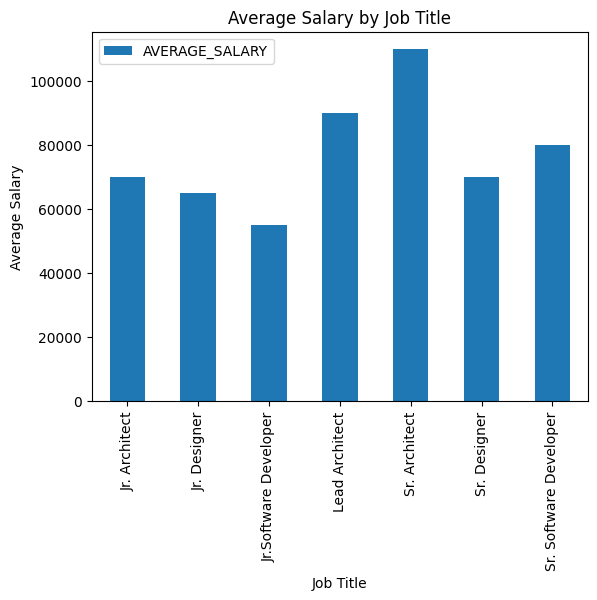

In [488]:
df.plot(kind="bar", x="JOB_TITLE", y="AVERAGE_SALARY", title="Average Salary by Job Title")
plt.ylabel("Average Salary")
plt.xlabel("Job Title")
plt.show()

In [490]:
conn.close()